In [26]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Point to your statement.csv
file_path = ("/home/jackm/Downloads/CCStatement.csv")

df = pd.read_csv(file_path, dtype=str)
#print(df.head())

In [44]:
# Convert to df's
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Debit']  = pd.to_numeric(df['Debit'].str.replace(',', ''), errors='coerce')
df['Category'] = df['Category'].fillna('Uncategorized')
df['Description'] = df['Description'].fillna('No Description')

In [51]:
# Create a monthly columns
df['Month'] = df['Transaction Date'].dt.to_period('M')

# Sum spending per month
monthly_spending = df.groupby('Month')['Debit'].sum()
#print(monthly_spending)

In [46]:
def compute_monthly_spending(df):
    df = df.copy()
    df['Month'] = df['Transaction Date'].dt.to_period('M')
    return df.groupby('Month')['Debit'].sum()

In [47]:
# Sum debits for each Category & Month
cat_monthly = (
    df.groupby(['Month', 'Category'])['Debit']
      .sum()
      .unstack(fill_value=0)   # makes categories columns
)

In [48]:
def compute_category_monthly(df):
    df = df.copy()
    df['Month'] = df['Transaction Date'].dt.to_period('M')
    return (
        df.groupby(['Month', 'Category'])['Debit']
          .sum()
          .unstack(fill_value=0)
    )

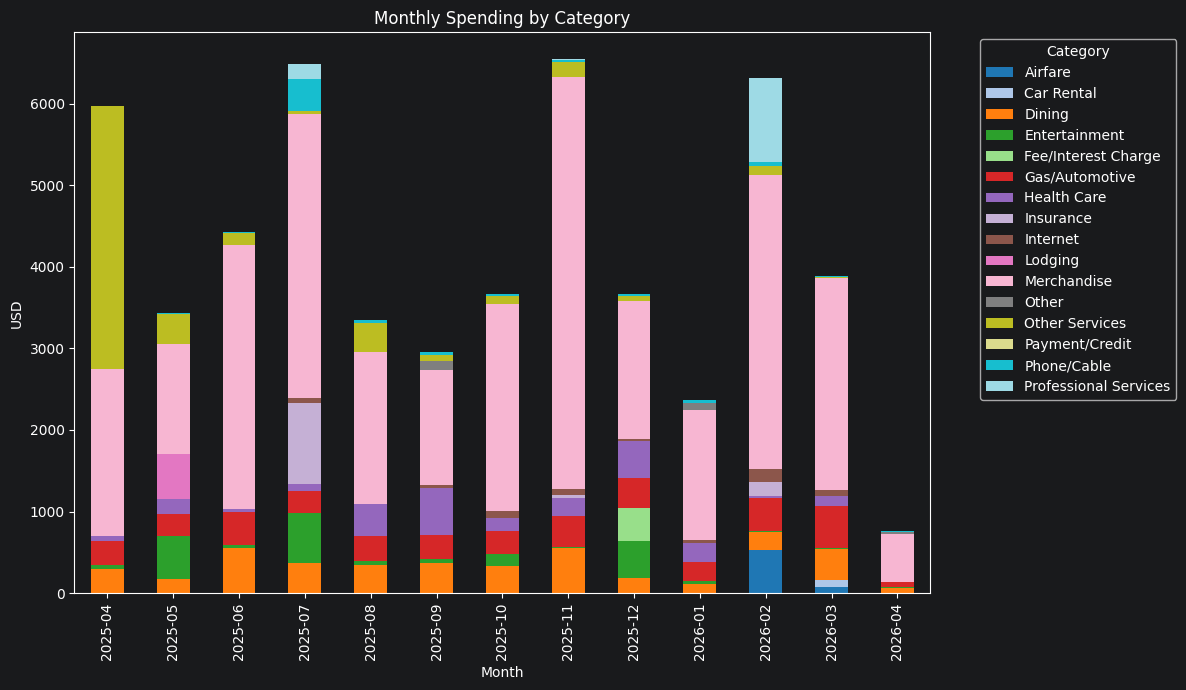

In [49]:
cat_monthly.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20')
plt.title('Monthly Spending by Category')
plt.ylabel('USD')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

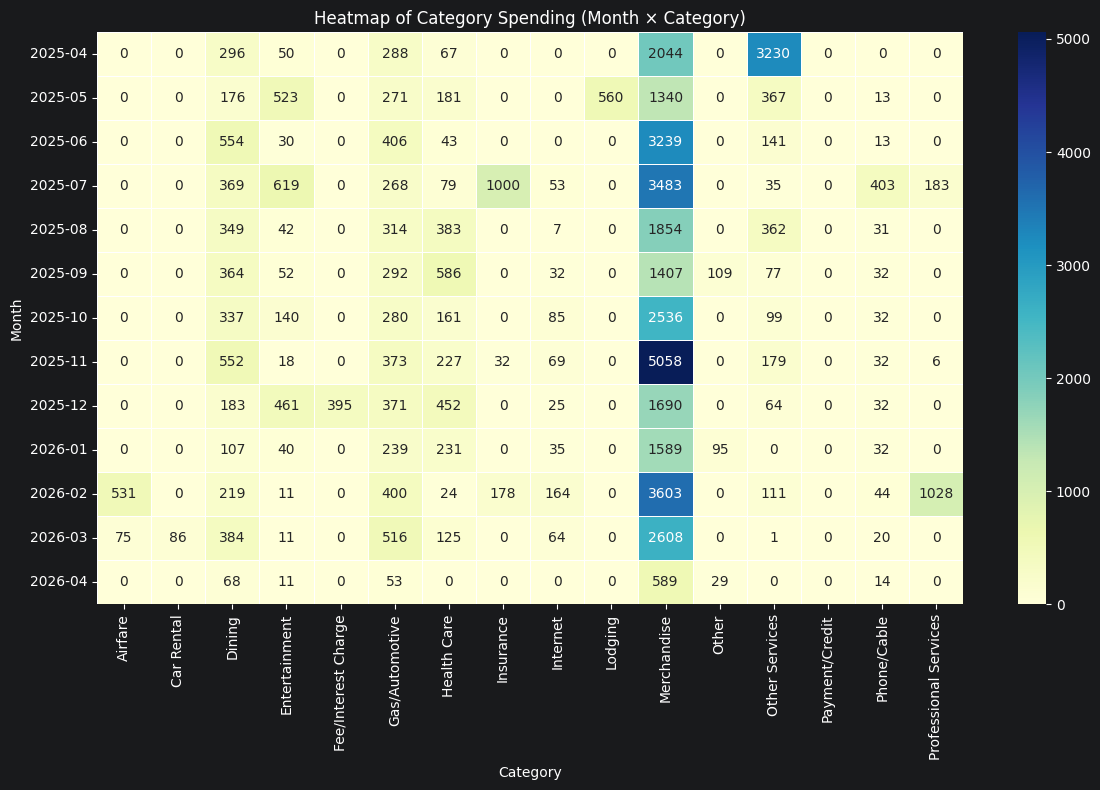

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(cat_monthly, cmap='YlGnBu', linewidths=.5, annot=True, fmt='.0f')
plt.title('Heatmap of Category Spending (Month × Category)')
plt.ylabel('Month')
plt.xlabel('Category')
plt.tight_layout()
plt.show()